In [2]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Находим корень проекта (поднимаемся на уровень выше папки notebooks)
root = Path.cwd().parent
sys.path.append(str(root))


from utils.analysis_pipeline import (
    load_and_preprocess,
    create_epochs,
    save_epochs,
    plot_epochs_images,
)
from utils.config import ch_to_keep, best_ch_by_power
import torch
from omegaconf import OmegaConf

%matplotlib inline

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal, stats


import mne

# from mne_bids import (
#     BIDSPath,
#     find_matching_paths,
#     get_entity_vals,
#     read_raw_bids,
# )

from scipy.signal import stft
from intervaltree import Interval, IntervalTree
from tqdm import tqdm

import numpy as np
import matplotlib.pyplot as plt
from mne.filter import notch_filter
from scipy.signal import welch

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score
import numpy as np
import mne

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

	
import abc
from sklearn.decomposition import PCA

Extracting EDF parameters from /beegfs/home/t.samsonov/notebooks/Pirogov/PirogovDATA/2025-09-05_s11/session_1/NeoRec_2025-09-05_21-04-18.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 571999  =      0.000 ...   286.000 secs...
NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 1.024 (s)


/beegfs/home/t.samsonov/notebooks/Pirogov/MNE_playground/utils/analysis_pipeline.py:45: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw.plot_psd()


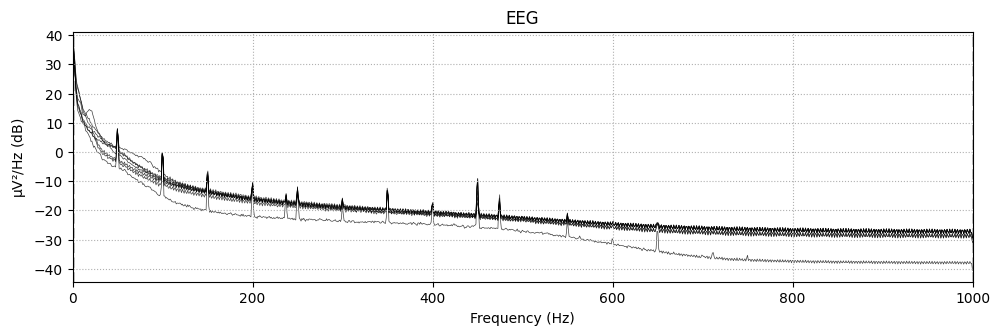

Extracting EDF parameters from /beegfs/home/t.samsonov/notebooks/Pirogov/PirogovDATA/2025-09-05_s11/session_2/NeoRec_2025-09-05_21-19-05.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 1703999  =      0.000 ...   852.000 secs...
NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 1.024 (s)


/beegfs/home/t.samsonov/notebooks/Pirogov/MNE_playground/utils/analysis_pipeline.py:45: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw.plot_psd()


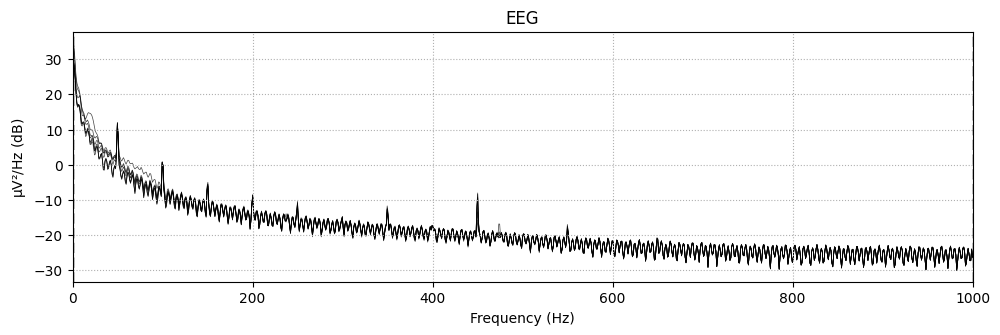

In [2]:
files_list = {}
root = "../../PirogovDATA/"
subject = "s11"

files_list[subject] = load_and_preprocess(root, subject)

# New

In [ ]:
# =======================
# Preprocessing: notch + bandpass -> global average reference (CAR)
# (place between load_and_preprocess(...) and create_epochs(...))
# =======================

clean = {subject: []}
sfreq = 2000  # пример

events_avg = [1, 2, 3, 4, 5, 6, 7, 8, 10]
event_single = [9]

# параметры (подстрой при необходимости)
notch_freqs = np.arange(50, sfreq // 2, 50)   # 50,100,150,... до Найквиста
l_freq, h_freq = 1.0, 150.0                   # bandpass

for i, raw in enumerate(files_list[subject]):
    r = raw.copy().load_data()  # важно: фильтры требуют данных в памяти

    # 1) notch (сетевой шум и гармоники)
    r.notch_filter(freqs=notch_freqs, n_jobs=-1)

    # 2) bandpass
    r.filter(l_freq=l_freq, h_freq=h_freq, method='iir')

    # 3) global average reference (CAR): x_i(t) <- x_i(t) - mean_j x_j(t)
    X = r.get_data()                         # (n_ch, n_times)
    X = X - X.mean(axis=0, keepdims=True)    # вычитаем среднее по каналам

    # создаём RawArray с корректным info
    info = r.info.copy()
    r_car = mne.io.RawArray(X, info)

    # переносим аннотации (события)
    r_car.set_annotations(r.annotations)

    # (опционально) если хочешь быстро проверить PSD после CAR
    # r_car.plot_psd(fmax=250); plt.show()

    clean[subject].append(r_car)

# дальше по твоему коду:
# epochs = create_epochs(clean, subject, event_id=[*events_avg, *event_single])[0]


NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 1.024 (s)


/tmp/ipykernel_3815977/2526632107.py:2: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  data.plot_psd()


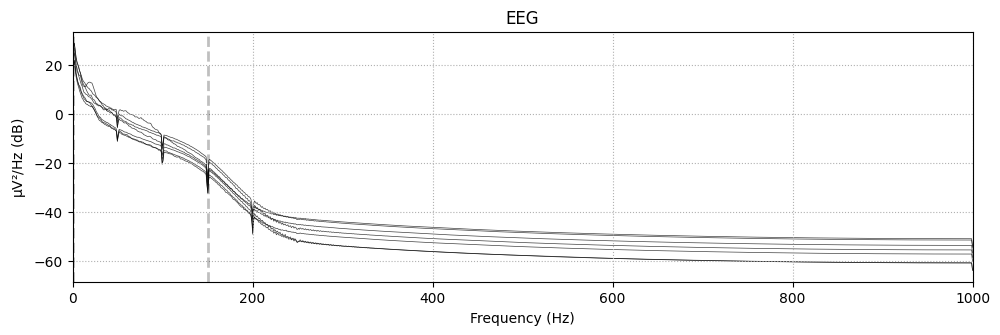

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 1.024 (s)


/tmp/ipykernel_3815977/2526632107.py:2: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  data.plot_psd()


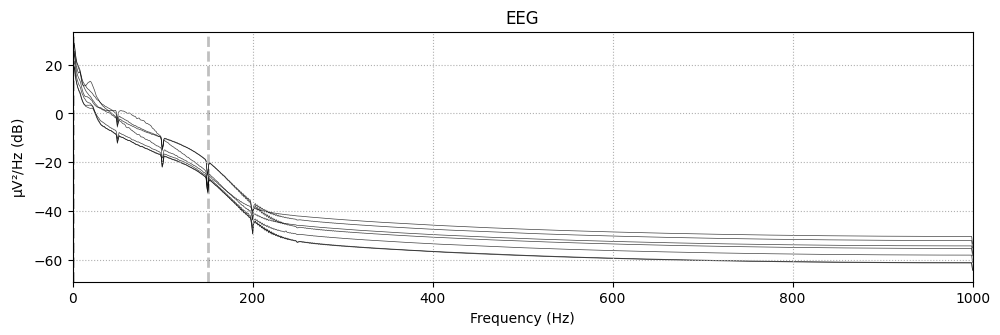

In [6]:
for i, data in enumerate(clean[subject]):
    data.plot_psd()
    plt.show()

In [7]:
epochs = create_epochs(clean, subject, event_id=[*events_avg, *event_single])[0] # return epochs_list, event_dict
# [0.1, 1.3, ..., 120]
freqs = np.linspace(0.1, 120, 100)  
# For each frequency, a specific number of cycles 
# is specified – the ‘window length’ in cycles.
n_cycles = freqs / 2.0              
tfr = mne.time_frequency.tfr_morlet(
    epochs[0], freqs=freqs, n_cycles=n_cycles, return_itc=False, decim=2, average=False
)
tfr.save(f"../tfr_{subject}.fif")

Not setting metadata
137 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 137 events and 4601 original time points ...
    Rejecting  epoch based on EEG : ['Tp7']
1 bad epochs dropped
Not setting metadata
403 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 403 events and 4601 original time points ...
    Rejecting  epoch based on EEG : ['Tp7']
    Rejecting  epoch based on EEG : ['Tp7']
2 bad epochs dropped
Not setting metadata


# cycle

Extracting EDF parameters from /beegfs/home/t.samsonov/notebooks/Pirogov/PirogovDATA/2025-05-05_s02/session_1/s02_session_1.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 973999  =      0.000 ...   487.000 secs...
NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 1.024 (s)


/beegfs/home/t.samsonov/notebooks/Pirogov/MNE_playground/utils/analysis_pipeline.py:45: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw.plot_psd()


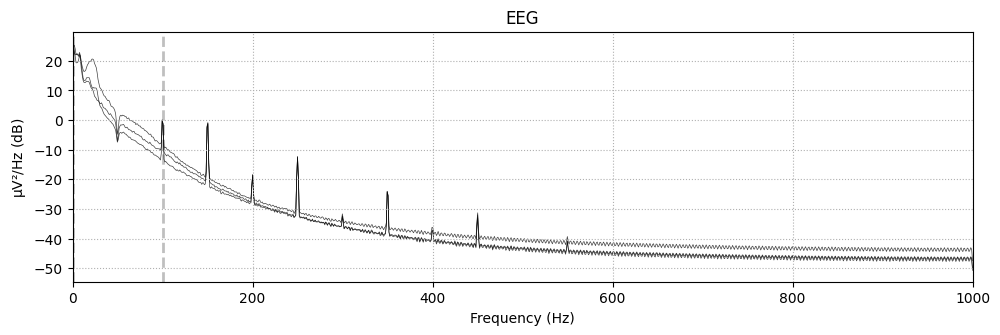

Extracting EDF parameters from /beegfs/home/t.samsonov/notebooks/Pirogov/PirogovDATA/2025-05-05_s02/session_4/s02_session_4.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 577999  =      0.000 ...   289.000 secs...
NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 1.024 (s)


/beegfs/home/t.samsonov/notebooks/Pirogov/MNE_playground/utils/analysis_pipeline.py:45: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw.plot_psd()


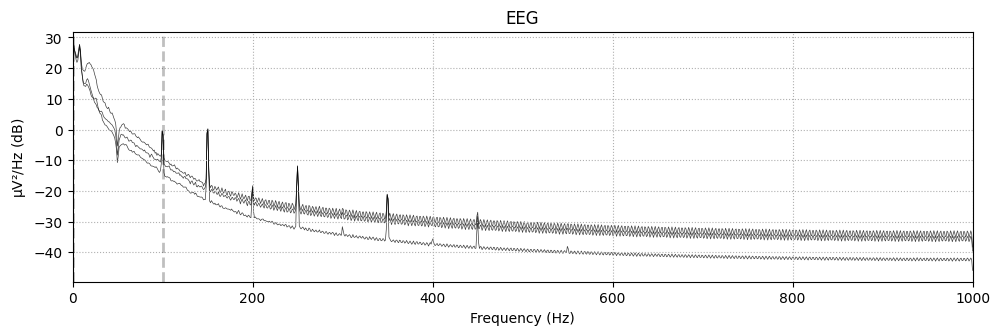

Extracting EDF parameters from /beegfs/home/t.samsonov/notebooks/Pirogov/PirogovDATA/2025-05-05_s02/session_2/s02_session_2.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 773999  =      0.000 ...   387.000 secs...
NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 1.024 (s)


/beegfs/home/t.samsonov/notebooks/Pirogov/MNE_playground/utils/analysis_pipeline.py:45: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw.plot_psd()


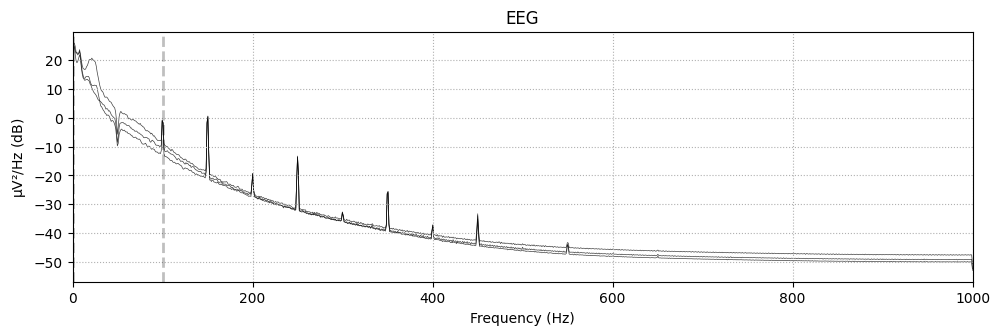

Extracting EDF parameters from /beegfs/home/t.samsonov/notebooks/Pirogov/PirogovDATA/2025-05-05_s02/session_3/s02_session_3.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 361999  =      0.000 ...   181.000 secs...
NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 1.024 (s)


/beegfs/home/t.samsonov/notebooks/Pirogov/MNE_playground/utils/analysis_pipeline.py:45: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw.plot_psd()


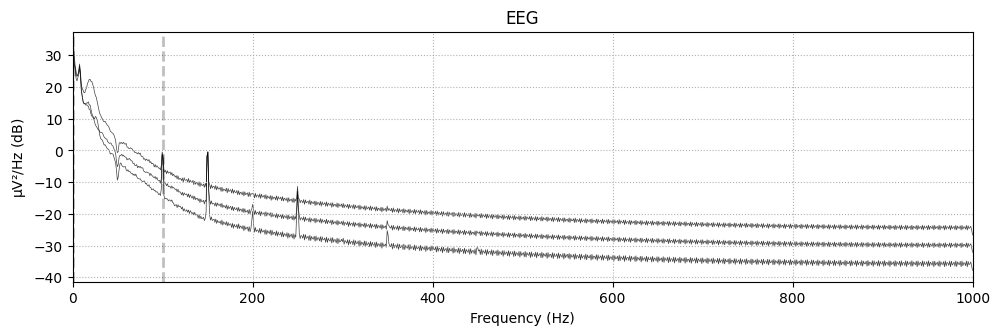

Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 13201 samples (6.601 sec)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 1.5e+02 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 1.00, 150.00 Hz: -6.02, -6.02 dB

Creating RawArray with float64 data, n_channels=3, n_times=974000
    Range : 0 ... 973999 =      0.000 ...   487.000 secs
Ready.
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) 

/tmp/ipykernel_3881542/225082848.py:46: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  data.plot_psd()


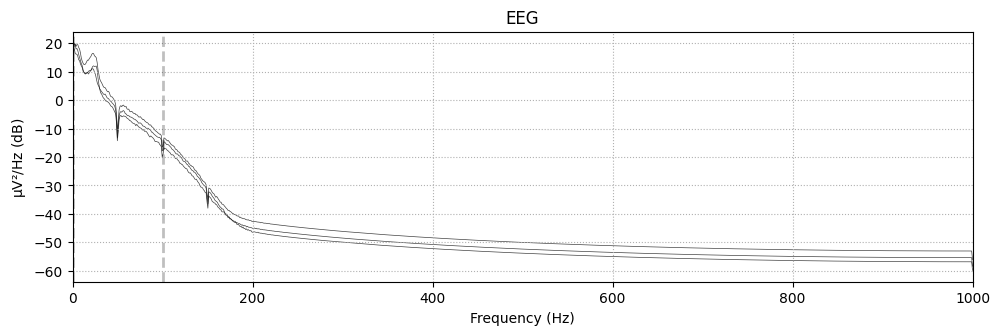

subject s02, file #1
NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 1.024 (s)


/tmp/ipykernel_3881542/225082848.py:46: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  data.plot_psd()


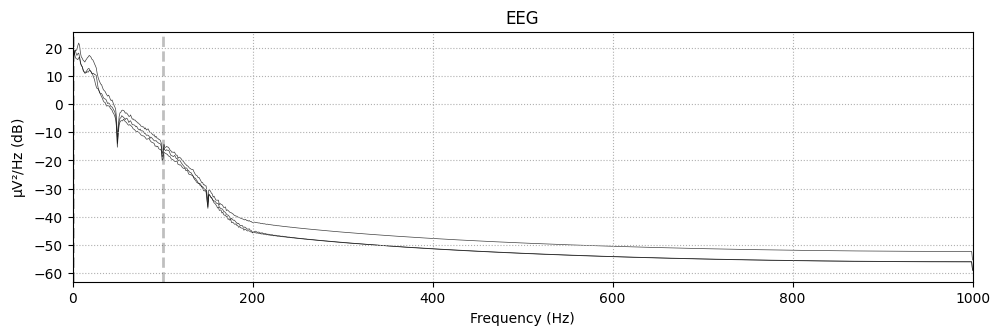

subject s02, file #2
NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 1.024 (s)


/tmp/ipykernel_3881542/225082848.py:46: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  data.plot_psd()


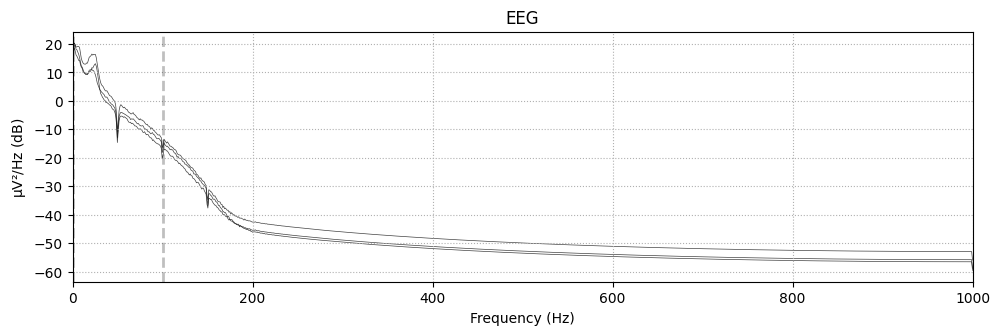

subject s02, file #3
NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 1.024 (s)


/tmp/ipykernel_3881542/225082848.py:46: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  data.plot_psd()


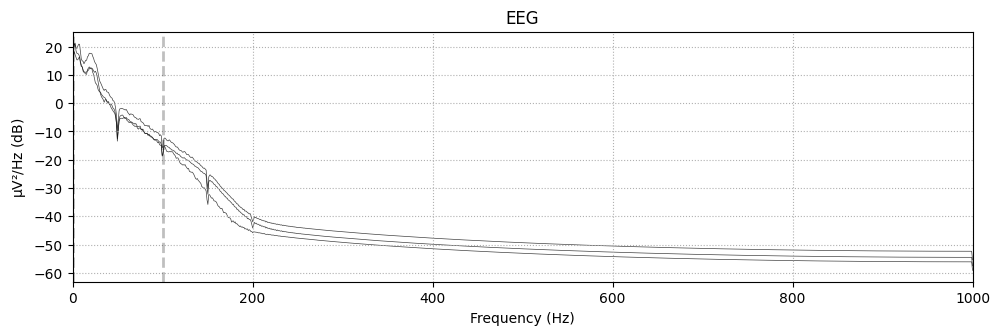

Not setting metadata
236 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 236 events and 4601 original time points ...
0 bad epochs dropped
Not setting metadata
139 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 139 events and 4601 original time points ...
1 bad epochs dropped
Not setting metadata
193 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 193 events and 4601 original time points ...
1 bad epochs dropped
Not setting metadata
87 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 87 events and 4601 original time points ...
1 bad epochs dropped
Not setting metadata
Extracting EDF parameters from /beegfs/home/t.samsonov/notebooks/Pirogov/PirogovDATA/2025-05-16_s03/session_1

/beegfs/home/t.samsonov/notebooks/Pirogov/MNE_playground/utils/analysis_pipeline.py:45: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw.plot_psd()


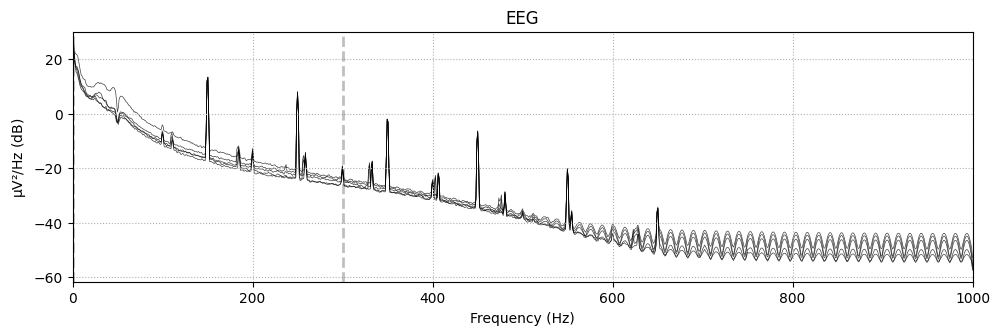

Extracting EDF parameters from /beegfs/home/t.samsonov/notebooks/Pirogov/PirogovDATA/2025-05-16_s03/session_2/s03_session_2.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 1427999  =      0.000 ...   714.000 secs...
NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 1.024 (s)


/beegfs/home/t.samsonov/notebooks/Pirogov/MNE_playground/utils/analysis_pipeline.py:45: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw.plot_psd()


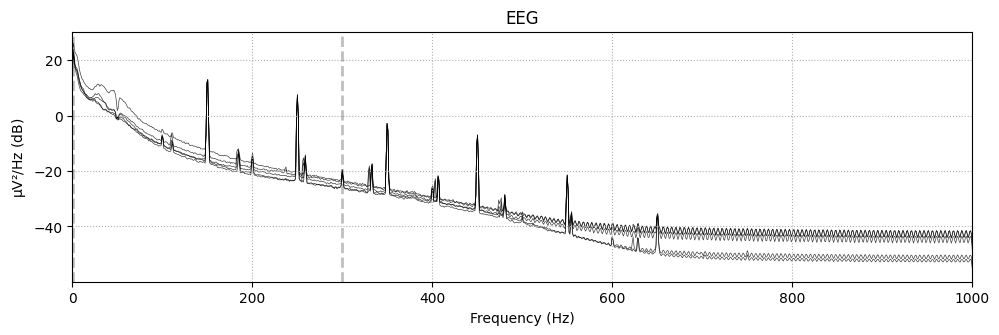

Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 13201 samples (6.601 sec)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 1.5e+02 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 1.00, 150.00 Hz: -6.02, -6.02 dB

Creating RawArray with float64 data, n_channels=5, n_times=972000
    Range : 0 ... 971999 =      0.000 ...   486.000 secs
Ready.
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) 

/tmp/ipykernel_3881542/225082848.py:46: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  data.plot_psd()


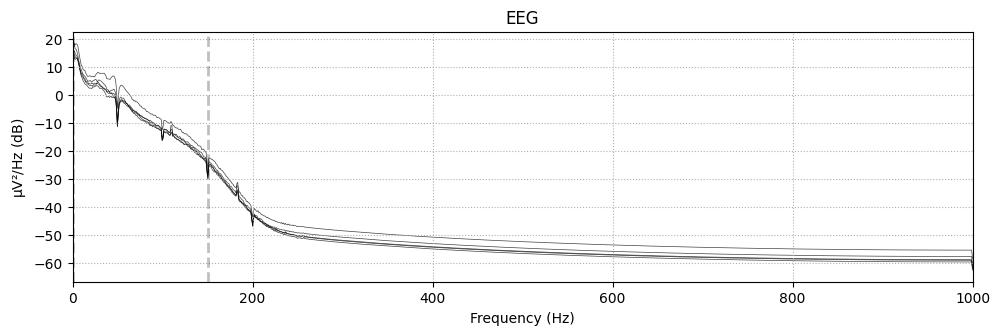

subject s03, file #1
NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 1.024 (s)


/tmp/ipykernel_3881542/225082848.py:46: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  data.plot_psd()


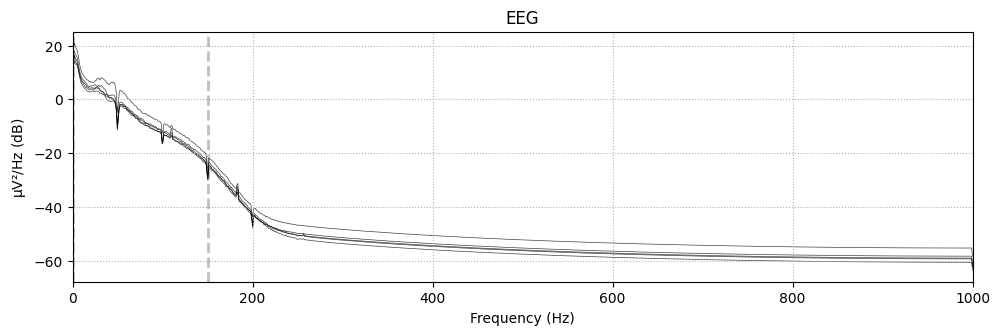

Not setting metadata
238 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 238 events and 4601 original time points ...
1 bad epochs dropped
Not setting metadata
348 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 348 events and 4601 original time points ...
0 bad epochs dropped
Not setting metadata
Extracting EDF parameters from /beegfs/home/t.samsonov/notebooks/Pirogov/PirogovDATA/2025-05-22_s04/session_1/s04_session_1.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 1051999  =      0.000 ...   526.000 secs...
NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 1.024 (s)


/beegfs/home/t.samsonov/notebooks/Pirogov/MNE_playground/utils/analysis_pipeline.py:45: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw.plot_psd()


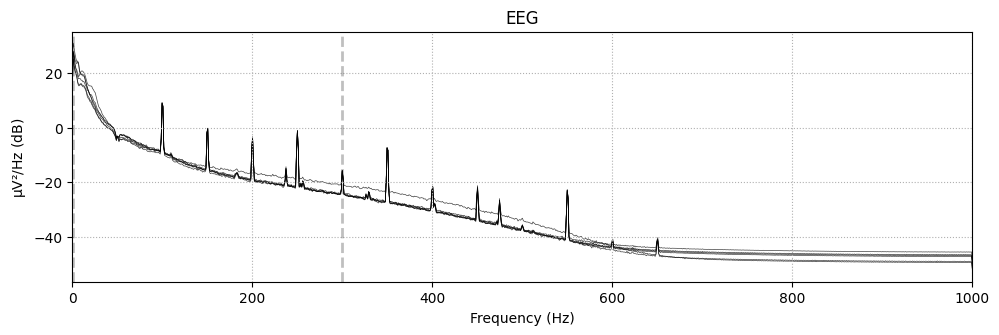

Extracting EDF parameters from /beegfs/home/t.samsonov/notebooks/Pirogov/PirogovDATA/2025-05-22_s04/session_2/s04_session_2.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 537999  =      0.000 ...   269.000 secs...
NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 1.024 (s)


/beegfs/home/t.samsonov/notebooks/Pirogov/MNE_playground/utils/analysis_pipeline.py:45: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw.plot_psd()


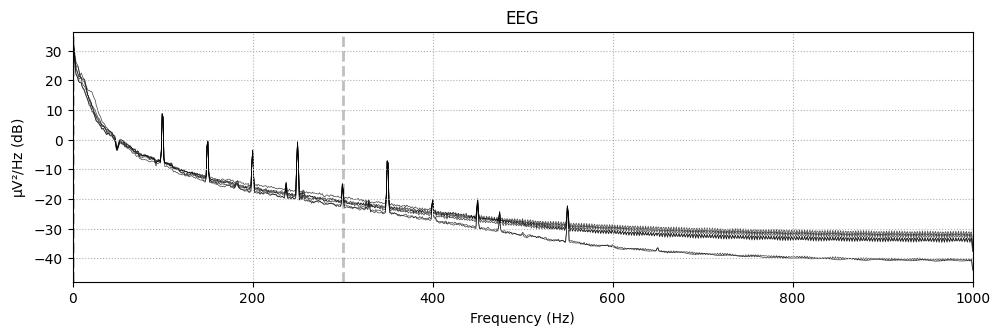

Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 13201 samples (6.601 sec)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 1.5e+02 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 1.00, 150.00 Hz: -6.02, -6.02 dB

Creating RawArray with float64 data, n_channels=6, n_times=1052000
    Range : 0 ... 1051999 =      0.000 ...   526.000 secs
Ready.
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin

/tmp/ipykernel_3881542/225082848.py:46: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  data.plot_psd()


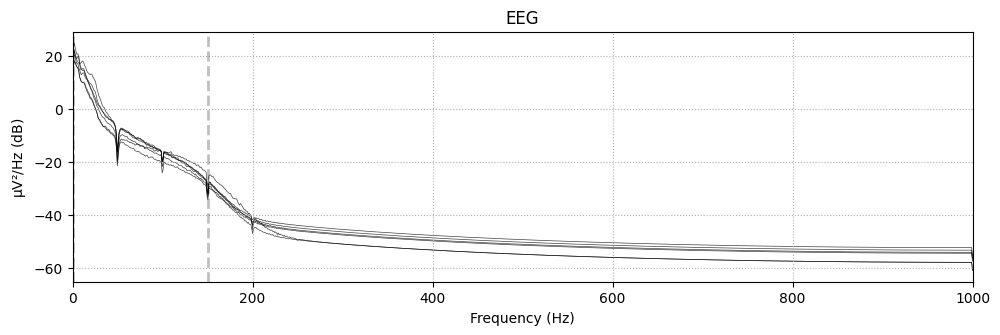

subject s04, file #1
NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 1.024 (s)


/tmp/ipykernel_3881542/225082848.py:46: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  data.plot_psd()


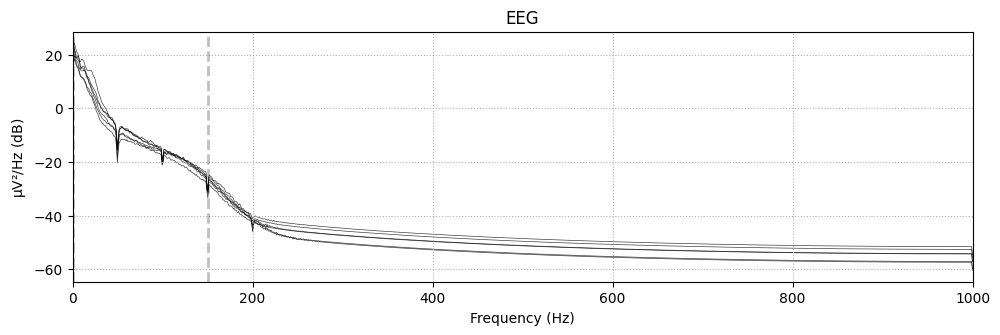

Not setting metadata
256 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 256 events and 4601 original time points ...
1 bad epochs dropped
Not setting metadata
131 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 131 events and 4601 original time points ...
0 bad epochs dropped


In [5]:
root = "../../PirogovDATA/"

for subject in list(best_ch_by_power.keys()):
    files_list = {}

    files_list[subject] = load_and_preprocess(root, subject)
    clean = {subject: []}
    sfreq = 2000  # пример

    events_avg = [1, 2, 3, 4, 5, 6, 7, 8, 10]
    event_single = [9]

    # параметры (подстрой при необходимости)
    notch_freqs = np.arange(50, sfreq // 2, 50)   # 50,100,150,... до Найквиста
    l_freq, h_freq = 1.0, 150.0                   # bandpass

    for i, raw in enumerate(files_list[subject]):
        r = raw.copy().load_data()  # важно: фильтры требуют данных в памяти

        # 1) notch (сетевой шум и гармоники)
        r.notch_filter(freqs=notch_freqs, n_jobs=-1)

        # 2) bandpass
        r.filter(l_freq=l_freq, h_freq=h_freq, method='iir')

        # 3) global average reference (CAR): x_i(t) <- x_i(t) - mean_j x_j(t)
        X = r.get_data()                         # (n_ch, n_times)
        X = X - X.mean(axis=0, keepdims=True)    # вычитаем среднее по каналам

        # создаём RawArray с корректным info
        info = r.info.copy()
        r_car = mne.io.RawArray(X, info)

        # переносим аннотации (события)
        r_car.set_annotations(r.annotations)

        # (опционально) если хочешь быстро проверить PSD после CAR
        # r_car.plot_psd(fmax=250); plt.show()

        clean[subject].append(r_car)

    # дальше по твоему коду:
    # epochs = create_epochs(clean, subject, event_id=[*events_avg, *event_single])[0]
    for i, data in enumerate(clean[subject]):
        print(f"subject {subject}, file #{i}")
        data.plot_psd()
        plt.show()

    epochs = create_epochs(clean, subject, event_id=[*events_avg, *event_single])[0] # return epochs_list, event_dict
    # [0.1, 1.3, ..., 120]
    freqs = np.linspace(0.1, 120, 100)  
    # For each frequency, a specific number of cycles 
    # is specified – the ‘window length’ in cycles.
    n_cycles = freqs / 2.0              
    tfr = mne.time_frequency.tfr_morlet(
        epochs[0], freqs=freqs, n_cycles=n_cycles, return_itc=False, decim=2, average=False
    )
    tfr.save(f"../specs_with_car/tfr_{subject}.fif")
    

# basement

In [ ]:
# # =======================
# # Local-average preprocessing block (between load_and_preprocess and create_epochs)
# # =======================

# import re
# import numpy as np
# import mne

# def _group_by_prefix(ch_names, pattern=r"^([A-Za-z]+)\d+$"):
#     """
#     Группирует каналы по буквенной части имени: A1,A2 -> группа 'A'.
#     Подстрой pattern под ваш нейминг при необходимости.
#     """
#     groups = {}
#     for ch in ch_names:
#         m = re.match(pattern, ch)
#         if m:
#             groups.setdefault(m.group(1), []).append(ch)
#     return groups

# def apply_local_average_reference(raw, groups, exclude_self=True, copy=True, verbose=True):
#     """
#     Local average reference:
#       x_i <- x_i - mean(neighbors)
#     где neighbors — остальные каналы в той же группе (обычно один электрод/стрип).

#     groups: dict[str, list[str]]  (например {"A": ["A1","A2",...], "B":[...]} )
#     exclude_self=True => вычитаем среднее по группе без самого канала (обычно так и надо).

#     Важно: это НЕ MNE-проекция, мы реально меняем данные в raw._data.
#     """
#     if copy:
#         raw = raw.copy()

#     data = raw.get_data()  # shape (n_ch, n_times)
#     name_to_idx = {ch: i for i, ch in enumerate(raw.ch_names)}

#     used_groups = 0
#     touched = 0

#     for gname, chs in groups.items():
#         idxs = [name_to_idx[ch] for ch in chs if ch in name_to_idx]
#         if len(idxs) < 2:
#             continue

#         grp = data[idxs, :]  # (Cg, T)

#         if exclude_self:
#             # x_k - mean(others)
#             sum_all = np.sum(grp, axis=0, keepdims=True)  # (1, T)
#             denom = (len(idxs) - 1)
#             for k, ci in enumerate(idxs):
#                 mean_others = (sum_all - grp[k:k+1]) / denom
#                 data[ci, :] = data[ci, :] - mean_others[0]
#                 touched += 1
#         else:
#             mean_all = np.mean(grp, axis=0)
#             for ci in idxs:
#                 data[ci, :] = data[ci, :] - mean_all
#                 touched += 1

#         used_groups += 1

#     # записываем обратно
#     raw._data = data

#     if verbose:
#         print(f"[local-average] groups_used={used_groups}, channels_referenced={touched}")

#     return raw

# # --- Собираем и применяем local average reference + (опционально) notch ---
# clean = {subject: []}

# # Если ваши каналы не формата A1/A2/... — лучше вручную задать groups_map.
# # Авто-группировка по паттерну:
# # - если у вас названия вроде "LA1", "LA2" — pattern можно оставить
# # - если что-то вроде "A01" или "A-01" — поменяй regex
# pattern = r"^([A-Za-z]+)\d+$"

# for i, raw in enumerate(files_list[subject]):
#     r = raw.copy()

#     # (1) notch как у тебя (если хочешь оставить этот шаг именно здесь)
#     r.notch_filter(freqs=np.arange(50, sfreq // 2, 50))

#     # (2) строим группы для local average (по именам каналов)
#     groups_map = _group_by_prefix(r.ch_names, pattern=pattern)

#     # (3) применяем local average reference
#     r = apply_local_average_reference(
#         r,
#         groups=groups_map,
#         exclude_self=True,
#         copy=False,      # уже копировали выше
#         verbose=True
#     )

#     # (4) быстрый sanity-check PSD после local average
#     # r.plot_psd(fmax=200); plt.show()

#     clean[subject].append(r)

# # дальше у тебя идет:
# # epochs = create_epochs(clean, subject, event_id=[*events_avg, *event_single])[0]
# Old
# sfreq = 2000  # пример
# channel = "Fp1"

# events_avg = [1, 2, 3, 4, 5, 6, 7, 8, 10]
# event_single = [9]

# clean = {subject: []}

# for i, data in enumerate(files_list[subject]):

#     clean[subject].append(data.copy().notch_filter(freqs=np.arange(50, sfreq // 2, 50)))
#     clean[subject][i].plot_psd()
#     plt.show()
# epochs = create_epochs(clean, subject, event_id=[*events_avg, *event_single])[0] # return epochs_list, event_dict
# epochs
# freqs = np.linspace(0.1, 120, 100)
# n_cycles = freqs / 2.0
# tfr = mne.time_frequency.tfr_morlet(
#     epochs[0], freqs=freqs, n_cycles=n_cycles, return_itc=False, decim=2, average=False
# )
# tfr.save(f"../tfr_{subject}.fif")